In [1]:
import os
os.chdir(r"C:\Users\KHALID\Desktop\PROJECTS\Darija-Sentiment-Analysis")
print("✅ Dossier:", os.getcwd())


✅ Dossier: C:\Users\KHALID\Desktop\PROJECTS\Darija-Sentiment-Analysis


In [2]:
import os
os.makedirs("assets/images", exist_ok=True)
print("✅ Dossier créé!")

✅ Dossier créé!


# 📊 Notebook 01 — Data Exploration
## Darija Sentiment Analysis — خالد مرجان

**Objective:** Understand the dataset before training any model.

- Label distribution
- Text length analysis
- Script distribution (Arabic / Arabizi / Mixed)
- Most frequent words per sentiment
- Source distribution

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
from collections import Counter

# Arabic font support
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-darkgrid')

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Dataset

In [4]:
# Load all splits
df_full  = pd.read_csv('data/unified/darija_sentiment_unified.csv', encoding='utf-8-sig')
df_train = pd.read_csv('data/splits/train.csv', encoding='utf-8-sig')
df_val   = pd.read_csv('data/splits/val.csv',   encoding='utf-8-sig')
df_test  = pd.read_csv('data/splits/test.csv',  encoding='utf-8-sig')

print(f'Full dataset : {len(df_full):,} rows')
print(f'Train split  : {len(df_train):,} rows')
print(f'Val split    : {len(df_val):,} rows')
print(f'Test split   : {len(df_test):,} rows')
print()
print('Columns:', df_full.columns.tolist())
df_full.head()

Full dataset : 8,619 rows
Train split  : 6,031 rows
Val split    : 1,294 rows
Test split   : 1,294 rows

Columns: ['text', 'label', 'source', 'writing_style']


,text,label,source,writing_style
0,m3alem bourjilia w illi ma yefehmouch yelzmou ...,positive,kaggle_moroccan_sentiment,mixed
1,Ya m3alllam,positive,kaggle_moroccan_sentiment,mixed
2,Ma7lek! Zin ou fannena 7loua.,positive,kaggle_moroccan_sentiment,mixed
3,hhhhh ya bliiiiiiiida ya Hanen,negative,kaggle_moroccan_sentiment,mixed
4,Nikraha w ma5yebha pffff,negative,kaggle_moroccan_sentiment,mixed


## 2. Label Distribution

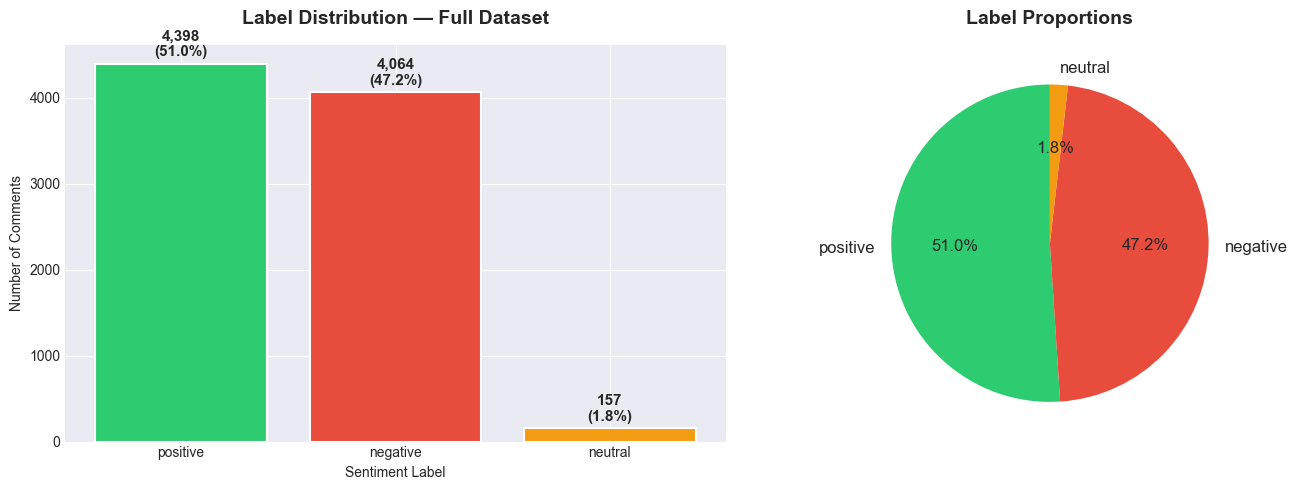

✅ Saved: assets/images/label_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors
colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#F39C12'}
label_colors = [colors.get(l, '#95A5A6') for l in df_full['label'].value_counts().index]

# Bar chart
counts = df_full['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=label_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Label Distribution — Full Dataset', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Comments')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/len(df_full)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=label_colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Label Proportions', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('assets/images/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: assets/images/label_distribution.png')

## 3. Data Source Distribution

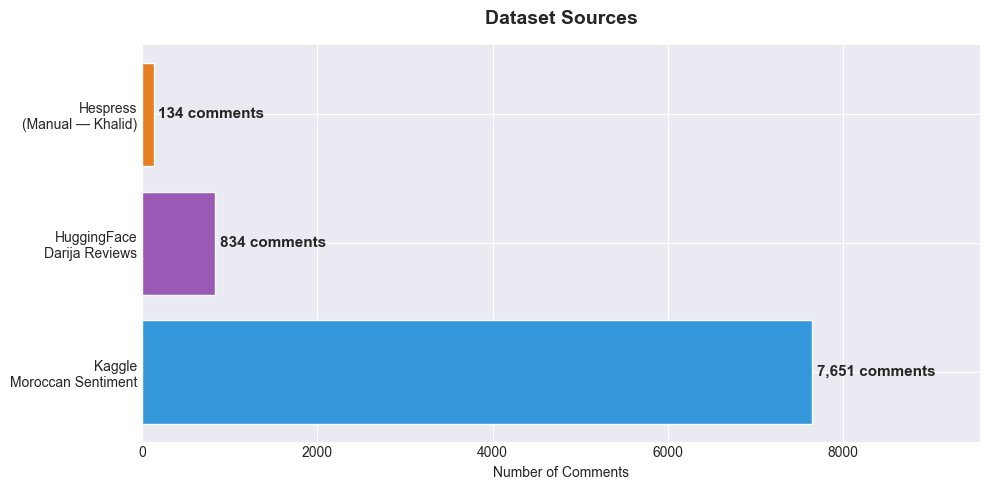

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

source_counts = df_full['source'].value_counts()
source_labels = [
    'Kaggle\nMoroccan Sentiment',
    'HuggingFace\nDarija Reviews',
    'Hespress\n(Manual — Khalid)'
]
source_colors = ['#3498DB', '#9B59B6', '#E67E22']

bars = ax.barh(source_labels[:len(source_counts)], source_counts.values,
               color=source_colors[:len(source_counts)], edgecolor='white')

for bar, count in zip(bars, source_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{count:,} comments', va='center', fontsize=11, fontweight='bold')

ax.set_title('Dataset Sources', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Comments')
ax.set_xlim(0, source_counts.max() * 1.25)
plt.tight_layout()
plt.savefig('assets/images/source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Length Analysis

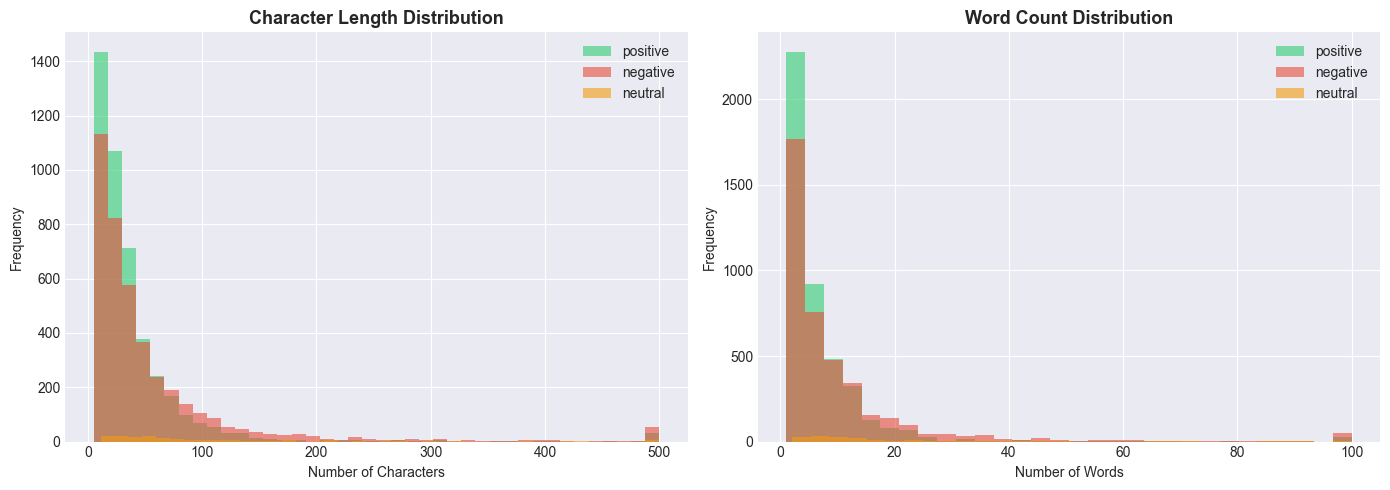


📏 Text Length Statistics:
           count   mean    std   min   25%   50%    75%     max
label                                                          
negative  4064.0   70.3  222.7   5.0  16.0  31.0   62.0  4591.0
neutral    157.0  104.3  121.0  11.0  36.0  59.0  119.0   634.0
positive  4398.0   48.5  190.8   5.0  15.0  25.0   45.0  5287.0

📝 Word Count Statistics:
           count  mean   std  min  25%   50%   75%    max
label                                                    
negative  4064.0  12.4  38.2  1.0  3.0   5.0  11.0  728.0
neutral    157.0  18.6  20.1  2.0  7.0  11.0  23.0  106.0
positive  4398.0   8.4  31.7  1.0  2.0   4.0   8.0  874.0


In [7]:
df_full['text_length'] = df_full['text'].str.len()
df_full['word_count']  = df_full['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in ['positive', 'negative', 'neutral']:
    subset = df_full[df_full['label'] == label]
    color  = colors[label]
    axes[0].hist(subset['text_length'].clip(upper=500), bins=40,
                 alpha=0.6, label=label, color=color)
    axes[1].hist(subset['word_count'].clip(upper=100), bins=30,
                 alpha=0.6, label=label, color=color)

axes[0].set_title('Character Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('assets/images/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📏 Text Length Statistics:')
print(df_full.groupby('label')['text_length'].describe().round(1))
print('\n📝 Word Count Statistics:')
print(df_full.groupby('label')['word_count'].describe().round(1))

## 5. Writing Style Distribution

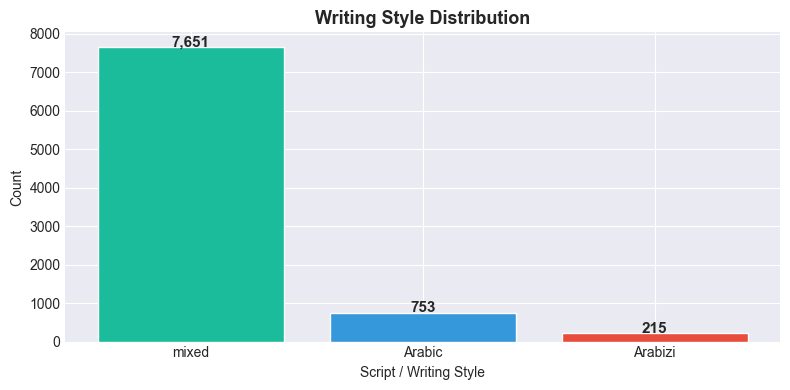

writing_style
mixed      7651
Arabic      753
Arabizi     215
Name: count, dtype: int64


In [8]:
if 'writing_style' in df_full.columns:
    style_counts = df_full['writing_style'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    style_colors = ['#1ABC9C', '#3498DB', '#E74C3C', '#F39C12']
    bars = ax.bar(style_counts.index, style_counts.values,
                  color=style_colors[:len(style_counts)], edgecolor='white')
    for bar, count in zip(bars, style_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{count:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title('Writing Style Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Script / Writing Style')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig('assets/images/writing_style.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(style_counts)

## 6. Most Frequent Words Per Sentiment

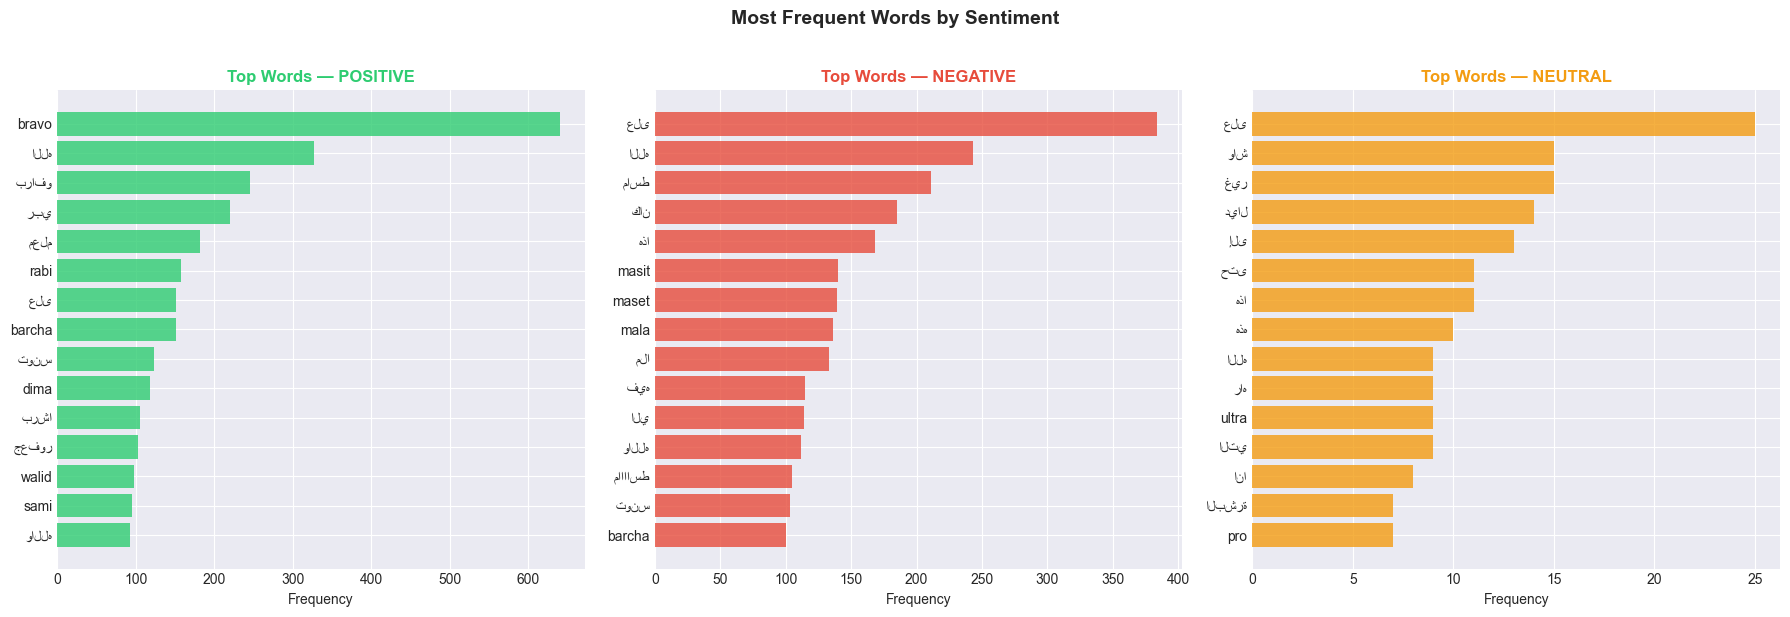

In [9]:
def get_top_words(df, label, n=20):
    texts = df[df['label'] == label]['text'].dropna()
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        # Filter short words and punctuation
        words = [w for w in words if len(w) > 2 and w.isalpha()]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, label in enumerate(['positive', 'negative', 'neutral']):
    top_words = get_top_words(df_full, label, n=15)
    words  = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]
    
    color = colors[label]
    axes[idx].barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    axes[idx].set_title(f'Top Words — {label.upper()}',
                        fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/images/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train/Val/Test Split Summary

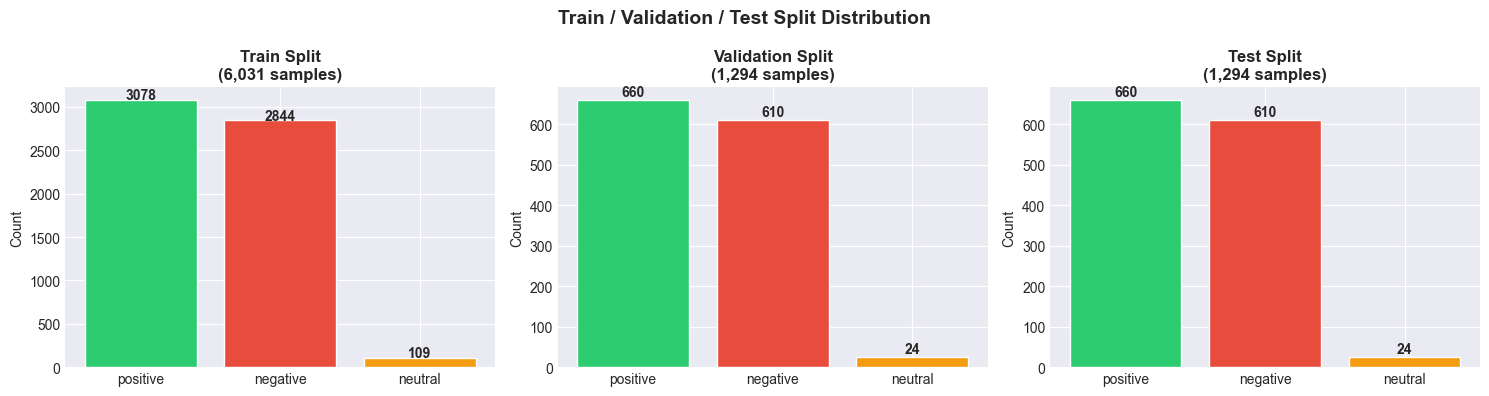


✅ Exploration complete! All charts saved to assets/images/

📊 Dataset Summary:
  Total samples : 8,619
  Train         : 6,031 (70%)
  Validation    : 1,294 (15%)
  Test          : 1,294 (15%)

  Ready for Model Training → Notebook 02


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, df) in enumerate([('Train', df_train), ('Validation', df_val), ('Test', df_test)]):
    counts = df['label'].value_counts()
    label_colors_list = [colors.get(l, '#95A5A6') for l in counts.index]
    axes[idx].bar(counts.index, counts.values, color=label_colors_list, edgecolor='white')
    axes[idx].set_title(f'{name} Split\n({len(df):,} samples)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count')
    for i, (label, count) in enumerate(counts.items()):
        axes[idx].text(i, count + 10, str(count), ha='center', fontweight='bold')

plt.suptitle('Train / Validation / Test Split Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/images/splits_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Exploration complete! All charts saved to assets/images/')
print('\n📊 Dataset Summary:')
print(f'  Total samples : {len(df_full):,}')
print(f'  Train         : {len(df_train):,} ({len(df_train)/len(df_full)*100:.0f}%)')
print(f'  Validation    : {len(df_val):,} ({len(df_val)/len(df_full)*100:.0f}%)')
print(f'  Test          : {len(df_test):,} ({len(df_test)/len(df_full)*100:.0f}%)')
print(f'\n  Ready for Model Training → Notebook 02')